In [1]:
# 1: Data Exploration / Collection
# https://www.kaggle.com/datasets/lyhatt/house-prices-in-malaysia-2025
import pandas as pd
df = pd.read_csv('malaysia_house_price_data_2025.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Township      2000 non-null   object
 1   Area          2000 non-null   object
 2   State         2000 non-null   object
 3   Tenure        2000 non-null   object
 4   Type          2000 non-null   object
 5   Median_Price  2000 non-null   int64 
 6   Median_PSF    2000 non-null   int64 
 7   Transactions  2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [2]:
# 2: Data Preprocessing
# a. Checking Missing Value and Data Redundancy
print("✅ Missing values summary:\n", df.isnull().sum())
print("\n🌀 Total duplicated rows:", df.duplicated().sum())

✅ Missing values summary:
 Township        0
Area            0
State           0
Tenure          0
Type            0
Median_Price    0
Median_PSF      0
Transactions    0
dtype: int64

🌀 Total duplicated rows: 0


Before Cleaning:
Tenure
Freehold               1318
Leasehold               624
Freehold, Leasehold      31
Leasehold, Freehold      27
Name: count, dtype: int64




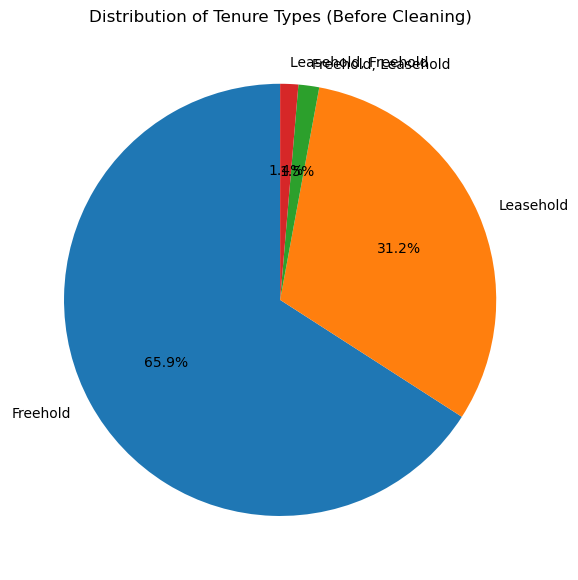


After Cleaning:
Tenure
freehold     1349
leasehold     651
Name: count, dtype: int64




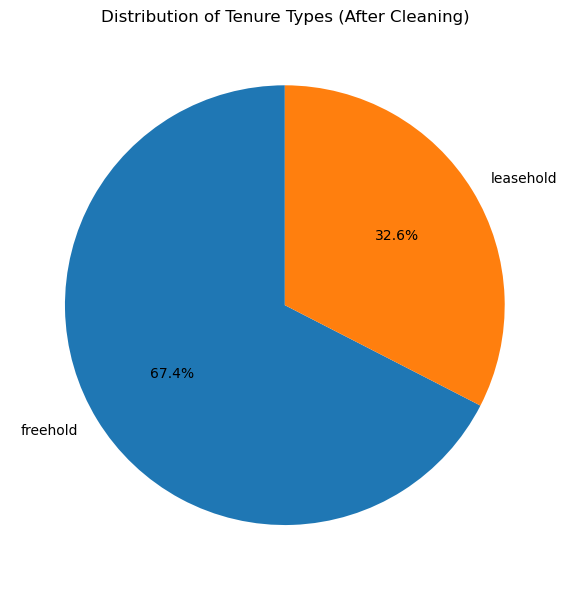

In [3]:
# b. Data Cleaning and Grouping ( Clean the 'Tenure' column for consistency)

import matplotlib.pyplot as plt
# Make a backup of the original 'Tenure' column for comparison
original_tenure = df['Tenure'].copy()

# Display the original 'Tenure' value counts (before cleaning)
print("Before Cleaning:")
print(original_tenure.value_counts())  # This shows the original, uncleaned data
print("\n")

# Count original tenure values
original_tenure_counts = original_tenure.value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
original_tenure_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Distribution of Tenure Types (Before Cleaning)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Clean the 'Tenure' column: strip spaces and convert to lowercase (for uniformity)
df['Tenure'] = df['Tenure'].str.strip().str.lower()

# Replace 'Freehold, Leasehold' with 'Freehold' and 'Leasehold, Freehold' with 'Leasehold'
df['Tenure'] = df['Tenure'].replace({
    'freehold, leasehold': 'freehold',  # Replace 'Freehold, Leasehold' with 'Freehold'
    'leasehold, freehold': 'leasehold'  # Replace 'Leasehold, Freehold' with 'Leasehold'
})

# Display the cleaned 'Tenure' value counts (after cleaning)
print("\nAfter Cleaning:")
print(df['Tenure'].value_counts())  # This shows the cleaned data
print("\n")
# Count cleaned tenure values
cleaned_tenure_counts = df['Tenure'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
cleaned_tenure_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Distribution of Tenure Types (After Cleaning)')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.show()

# Optionally save the cleaned data to a new Excel file
df.to_csv('cleaned_house_data.csv', index=False)  # Save cleaned data to a new file

# Save the original (uncleaned) data to another Excel file for comparison
original_df = pd.DataFrame({'Original_Tenure': original_tenure})
original_df.to_csv('original_house_data.csv', index=False)  # Save original data to a new file

Original Data:
State
Selangor           545
Johor              377
Perak              194
Penang             187
Kuala Lumpur       176
Negeri Sembilan    135
Kedah              103
Melaka              98
Pahang              71
Sarawak             54
Sabah               40
Terengganu          12
Putrajaya            3
Kelantan             3
Perlis               1
Labuan               1
Name: count, dtype: int64




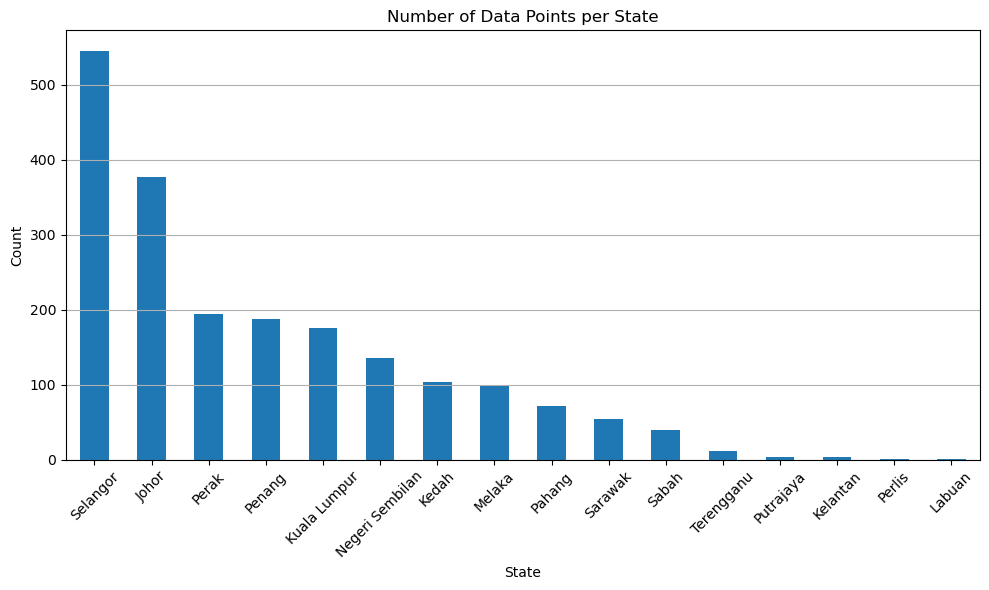

In [4]:
# 3. Feature Engineering
# a. Group states into regions

# Calculate the number of data points (rows) for each state and show bar chart
import matplotlib.pyplot as plt

print("Original Data:")
state_count = df['State'].value_counts()

# Display the state count in descending order
print(state_count)
print("\n")
# Plot bar chart
state_count.plot(kind='bar', figsize=(10, 6))

plt.title('Number of Data Points per State')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


 Grouping Data
                    Group  Count
0                   Johor    377
1            Kedah-Perlis    104
2                Kelantan      3
3                  Melaka     98
4         Negeri Sembilan    135
5                  Pahang     71
6                  Penang    187
7                   Perak    194
8    Sabah-Sarawak-Labuan     95
9   Selangor-KL-Putrajaya    724
10             Terengganu     12




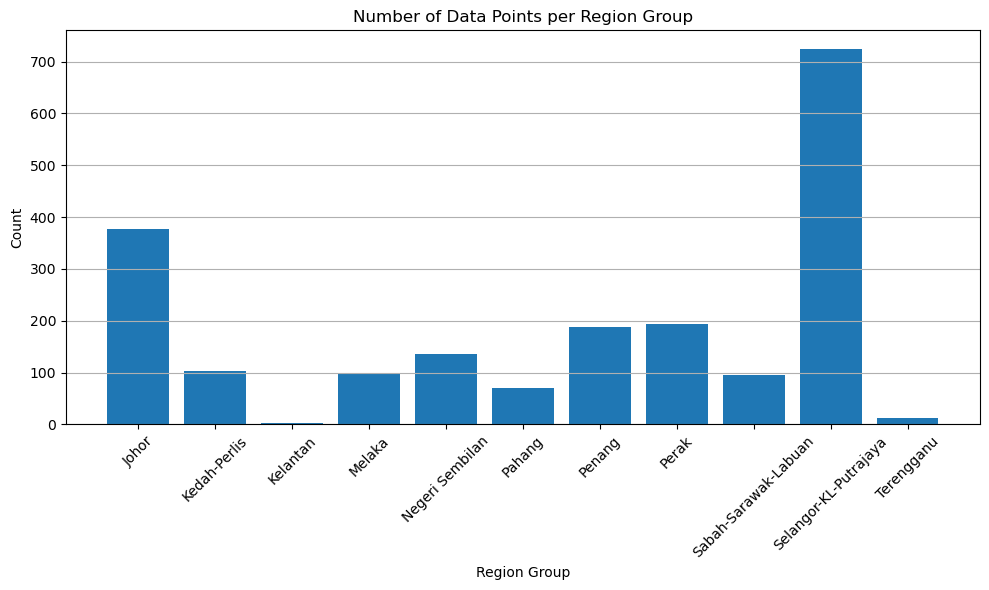

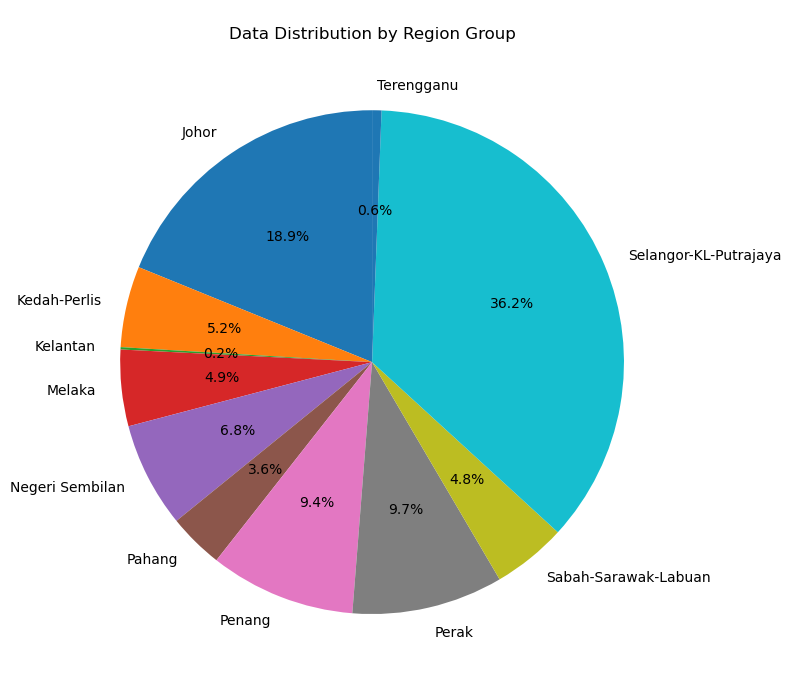

In [5]:
# Grouping State and showing bar, pie chart visualization
# Define the custom grouping based on your requirements
import matplotlib.pyplot as plt

state_group_mapping = {
    'Selangor': 'Selangor-KL-Putrajaya',
    'Kuala Lumpur': 'Selangor-KL-Putrajaya',
    'Putrajaya': 'Selangor-KL-Putrajaya',
    'Johor': 'Johor',
    'Perak': 'Perak',
    'Penang': 'Penang',
    'Negeri Sembilan': 'Negeri Sembilan',
    'Kedah': 'Kedah-Perlis',
    'Perlis': 'Kedah-Perlis',
    'Melaka': 'Melaka',
    'Pahang': 'Pahang',
    'Sarawak': 'Sabah-Sarawak-Labuan',
    'Sabah': 'Sabah-Sarawak-Labuan',
    'Labuan': 'Sabah-Sarawak-Labuan',
    'Terengganu': 'Terengganu',
    'Kelantan': 'Kelantan'
}

# Apply the mapping to create a new 'Group' column
df['Group'] = df['State'].map(state_group_mapping)

# Group the data by the 'Group' column and sum the counts (if you have a 'Count' column)
grouped_data = df.groupby('Group').size().reset_index(name='Count')

print("\n Grouping Data")
# Display the grouped data
print(grouped_data)
print("\n")

# Bar chart of grouped data
plt.figure(figsize=(10, 6))
plt.bar(grouped_data['Group'], grouped_data['Count'])

plt.title('Number of Data Points per Region Group')
plt.xlabel('Region Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Pie chart of grouped data
plt.figure(figsize=(8, 8))
plt.pie(grouped_data['Count'], labels=grouped_data['Group'], autopct='%1.1f%%', startangle=90)

plt.title('\nData Distribution by Region Group')
plt.tight_layout()
plt.show()

In [6]:
# b. Standarized house types
# Calculate the number of data points (rows) for each type
type_count = df['Type'].value_counts()

# Display the state count in descending order
print("\n Original Data")
print(type_count)

#too many data so visualization diagram is not available


 Original Data
Type
Terrace House                               956
Apartment                                   197
Condominium                                 167
Flat                                        131
Terrace House, Semi D                        99
Service Residence                            96
Semi D, Terrace House                        83
Semi D                                       43
Terrace House, Cluster House                 32
Cluster House                                24
Terrace House, Bungalow                      23
Cluster House, Terrace House                 23
Bungalow, Terrace House                      21
Bungalow, Semi D                             14
Bungalow                                     13
Terrace House, Town House                     9
Semi D, Bungalow                              8
Town House, Terrace House                     7
Town House                                    7
Cluster House, Semi D                         6
Semi D, Cluster Hou

Grouping Data
Type
terrace house    1127
apartment         596
semi d            205
bungalow           53
town house         19
Name: count, dtype: int64




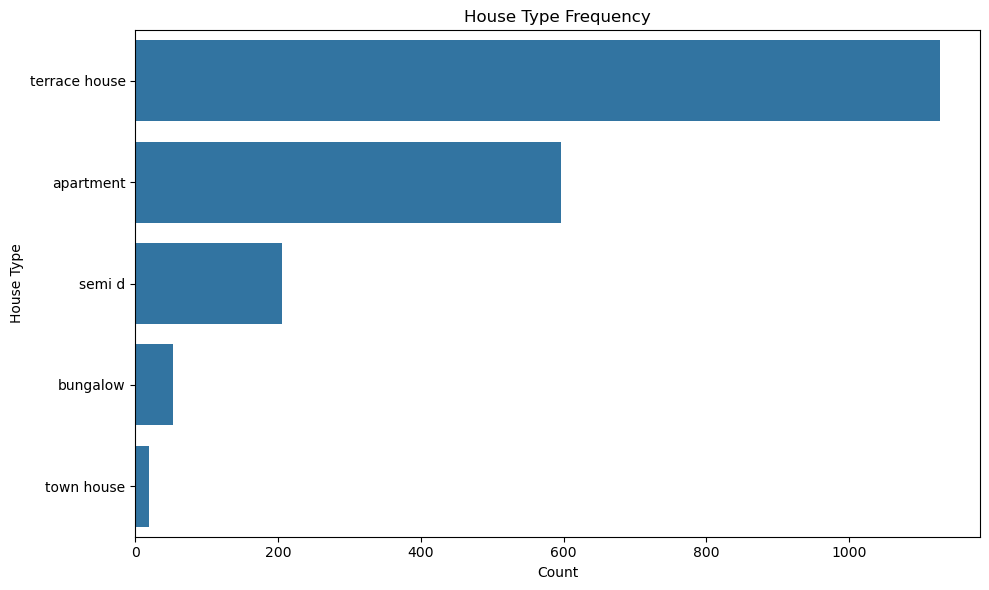

In [7]:
# Clean too many 'Type' and grouping them into a small group by showing 5. Count Plot (Seaborn) visualization
import seaborn as sns

df['Type'] = df['Type'].str.strip().str.lower()

# Define the mapping for similar house types (with lowercase to match cleaned data)
house_type_mapping = {
    'service residence': 'apartment',
    'flat': 'apartment',
    'condominium': 'apartment',
    'terrace house': 'terrace house',
    'semi d': 'semi d',
    'bungalow': 'bungalow',
    'town house': 'town house',
    'cluster house': 'semi d'  # Mapping cluster house to semi d for this case (adjust as needed)
}

# Function to standardize house types
def standardize_house_type(house_type):
    # Split the house type by commas
    types = house_type.split(',')
    
    # Remove extra spaces and lowercase the values
    types = [t.strip().lower() for t in types]
    
    # List to store matched standard types
    matched_types = []
    
    # Try to match each type with the mapping
    for t in types:
        if t in house_type_mapping:
            matched_types.append(house_type_mapping[t])  # Add the matched type
    
    # If no types matched, return the original type (in case of unexpected cases)
    if matched_types:
        # Return the first matched standard type (or any other logic you prefer)
        return matched_types[0]
    else:
        return house_type

# Apply the function to clean and standardize the 'Type' column
df['Type'] = df['Type'].apply(standardize_house_type)

print("Grouping Data")
# Display the cleaned 'Type' column and check the new counts
print(df['Type'].value_counts())
print("\n")

plt.figure(figsize=(10, 6))
sns.countplot(y='Type', data=df, order=df['Type'].value_counts().index)
plt.title('House Type Frequency')
plt.xlabel('Count')
plt.ylabel('House Type')
plt.tight_layout()
plt.show()

In [8]:
# 4: Exploratory Data Analysis (EDA)
# a: Statistical Summary  
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 Statistical Summary:")
print(df[['Median_PSF', 'Median_Price']].describe())
print("\n")

📊 Statistical Summary:
        Median_PSF  Median_Price
count  2000.000000  2.000000e+03
mean    328.862500  4.906854e+05
std     193.281739  4.686322e+05
min      38.000000  2.704900e+04
25%     201.000000  2.699500e+05
50%     293.000000  3.900000e+05
75%     412.000000  5.735000e+05
max    3017.000000  1.142050e+07




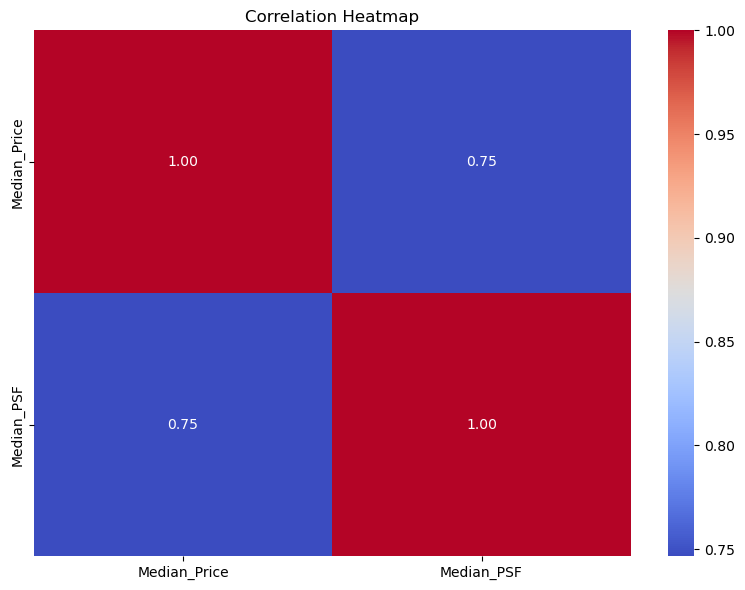

In [9]:
# b. Correlation matrix and heatmap
# Compute correlation matrix (only numerical columns)
corr = df.corr(numeric_only=True)
# For correlation, exclude it
corr = df.drop(columns=['Transactions']).corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show() 

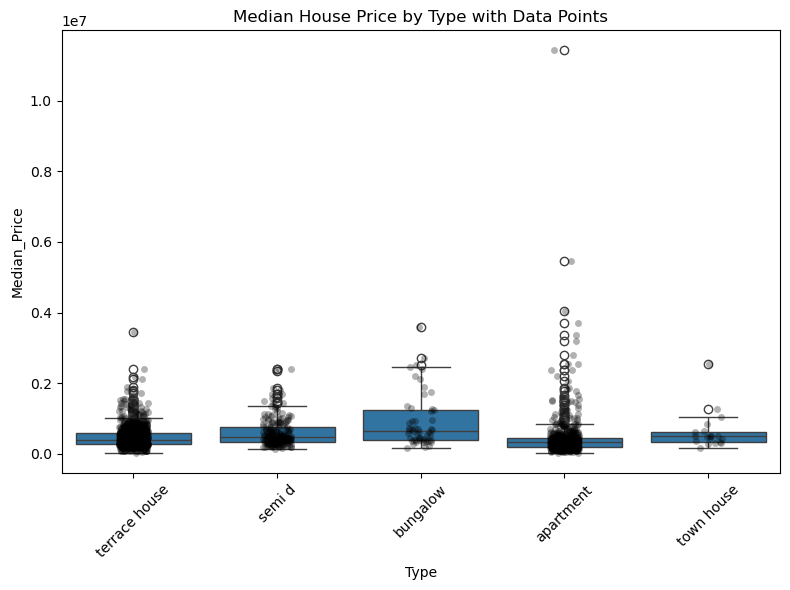

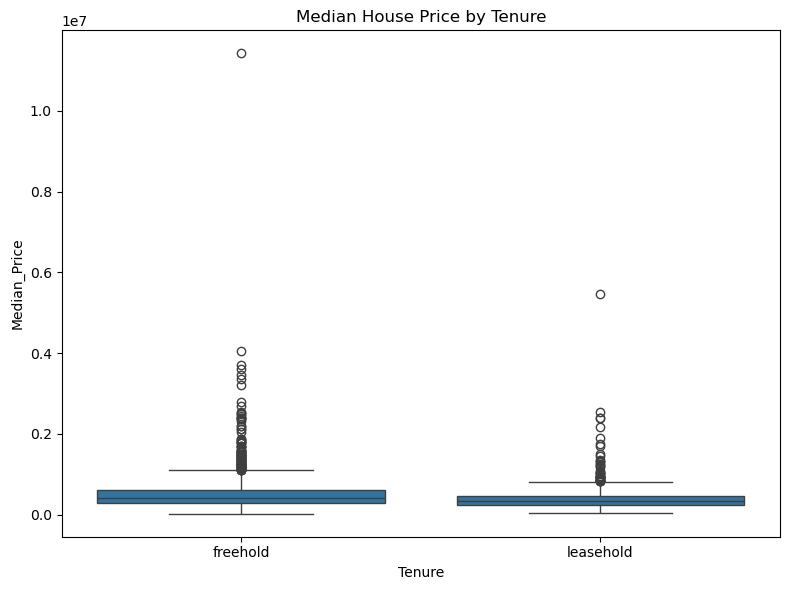

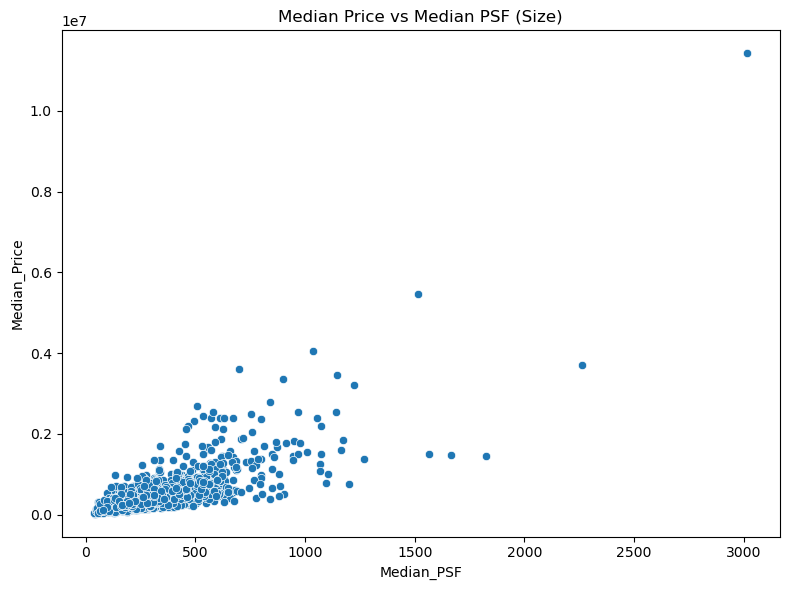

In [10]:
# c. Distribution plots for categorical variables and continuous variables

#  Visualizing the distribution and variability of the Median Price data
import seaborn as sns
import matplotlib.pyplot as plt

# First Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='Type', y='Median_Price', data=df)
sns.stripplot(x='Type', y='Median_Price', data=df, color='black', alpha=0.3, jitter=True)
plt.title('Median House Price by Type with Data Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Second Plot
print("\n")
plt.figure(figsize=(8,6))
sns.boxplot(x='Tenure', y='Median_Price', data=df)
plt.title('Median House Price by Tenure')
plt.tight_layout()
plt.show()

# Third Plot
print("\n")
plt.figure(figsize=(8,6))
sns.scatterplot(x='Median_PSF', y='Median_Price', data=df)
plt.title('Median Price vs Median PSF (Size)')
plt.tight_layout()
plt.show()

In [11]:
# 5: Model Training
# a. Define features and target
X = df[['State', 'Type', 'Tenure', 'Median_PSF']]
y = df['Median_Price']

# b. Prepare features and target variable
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# c. One-hot encode categorical features
categorical = ['State', 'Type', 'Tenure']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical)],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

# d. Train Linear Regression model using pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# e. Fit model
model.fit(X, y)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [12]:
# 6: Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np # for RMSE

# a: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Fit model on training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# b: Predict and evaluate using MAE, MSE, RMSE, and R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 158,535.17
Mean Squared Error (MSE): 92,454,621,231.34
Root Mean Squared Error (RMSE): 304,063.52
R-squared (R2 Score): 0.4744


In [13]:
# c: Display model coefficients
# Access the linear regression model from the pipeline
regressor = model.named_steps['regressor']

# Get feature names after one-hot encoding
# This requires verbose_feature_names_out=True in ColumnTransformer in newer sklearn versions
# Or manually constructing feature names if verbose_feature_names_out=False
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients
coefficients = regressor.coef_

print("\n--- Model Coefficients ---")
# Pair feature names with their coefficients
# Ensure the length matches, handle 'remainder' passthrough
if len(feature_names) == len(coefficients):
    coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    print(coeff_df.sort_values(by='Coefficient', ascending=False))
else:
    print("Could not easily map coefficients to feature names due to mismatched lengths.")
    print("Coefficients:", coefficients)


--- Model Coefficients ---
                  Feature    Coefficient
17          Type_bungalow  373867.491911
4            State_Labuan  206741.625696
13          State_Sarawak  101913.445048
18            Type_semi d   92125.415756
6   State_Negeri Sembilan   52378.705584
7            State_Pahang   48435.908719
1             State_Kedah   43384.359204
9             State_Perak   32493.474843
15       State_Terengganu   25318.388073
5            State_Melaka   18921.297160
23             Median_PSF    2306.919307
21        Tenure_freehold    1440.988564
22       Tenure_leasehold   -1440.988564
20        Type_town house   -7144.923083
3      State_Kuala Lumpur   -9458.674529
12            State_Sabah  -12147.173016
0             State_Johor  -15389.348580
14         State_Selangor  -36715.693729
10           State_Perlis  -40257.425960
8            State_Penang  -70219.254681
19     Type_terrace house -105952.945843
2          State_Kelantan -143730.324902
11        State_Putrajaya -20

In [14]:
# 7: Prediction (Using Machine Learning algorithm)
# Machine Learning algorithm prediction
import ipywidgets as widgets
from IPython.display import display

# Assume your model and df are already defined

# Widget options
state_options = sorted(df['State'].unique())
type_options = sorted(df['Type'].unique())
tenure_options = sorted(df['Tenure'].unique())

state_widget = widgets.Dropdown(options=state_options, description='State:')
type_widget = widgets.Dropdown(options=type_options, description='Type:')
tenure_widget = widgets.Dropdown(options=tenure_options, description='Tenure:')
size_widget = widgets.FloatText(value=400, description='Median_PSF:')
output = widgets.Output()

def predict_price(state, typ, tenure, median_psf):
    input_df = pd.DataFrame({
        'State': [state],
        'Type': [typ],
        'Tenure': [tenure],
        'Median_PSF': [median_psf]
    })
    price_predict = model.predict(input_df)[0]
    return price_predict

def validate_input():
    """Ensure all widgets have valid selections"""
    if not state_widget.value:
        return "Please select a valid state."
    if not type_widget.value:
        return "Please select a valid type."
    if not tenure_widget.value:
        return "Please select a valid tenure."
    return None  # All inputs are valid

def on_change(change):
    with output:
        output.clear_output()
        
        # Validate the inputs
        error_message = validate_input()
        if error_message:
            print(f"❌ Error: {error_message}")
            return  # Stop further processing if there's an error
        
        price = predict_price(
            state_widget.value,
            type_widget.value,
            tenure_widget.value,
            size_widget.value
        )
        print(f"✅ Predicted House Price: RM {price:,.2f}")

def update_type_tenure_options(change):
    selected_state = change['new']
    
    # Filter valid types and tenures
    valid_types = sorted(df[df['State'] == selected_state]['Type'].unique().tolist())
    valid_tenures = sorted(df[df['State'] == selected_state]['Tenure'].unique().tolist())

    # Update type_widget
    if valid_types:
        type_widget.options = valid_types
        type_widget.disabled = False
    else:
        type_widget.options = ["⚠ No house types available"]
        type_widget.disabled = True

    # Update tenure_widget
    if valid_tenures:
        tenure_widget.options = valid_tenures
        tenure_widget.disabled = False
    else:
        tenure_widget.options = ["⚠ No tenure available"]
        tenure_widget.disabled = True

    # Force re-prediction after options updated
    on_change(None)

# --- Observers ---
state_widget.observe(update_type_tenure_options, names='value')
for w in [state_widget, type_widget, tenure_widget, size_widget]:
    w.observe(on_change, names='value')

# --- Initial state ---
update_type_tenure_options({'new': state_widget.value})
display(widgets.VBox([state_widget, type_widget, tenure_widget, size_widget, output]))

# Show initial prediction
on_change(None)
